# Renko-Charts — does a noise-filtered chart beat a plain one?
### The brick chart's promise, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cleaner_signal%3F: Busted](https://img.shields.io/badge/Cleaner_signal%3F-Busted-8b949e?style=flat-square)

A **Renko chart** throws away time. Instead of one candle per day, it draws a new **brick** only when price moves a fixed amount. The result *looks* gorgeous: clean staircases, no clutter. Every charting platform sells the same promise — *"Renko filters out the noise, so your trend signals are cleaner and you get fewer false trades."* This notebook asks the only question that matters: does running a moving-average crossover on the Renko bricks actually beat running it on the plain daily price?

> **This is the plain-language layer.** Want the Sharpe ratios, the permutation placebo, and the synthetic positive control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c6fbb"

from renko_charts import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-05-31).
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'nbars': 5385, 'renko_S': 0.683, 'renko_t': 3.43, 'renko_ann': 6.78, 'renko_vol': 9.61, 'renko_dd': -17.8, 'raw_S': 0.685, 'raw_t': 3.43, 'raw_ann': 6.77, 'raw_vol': 9.56, 'raw_dd': -19.6, 'bh_S': 0.713, 'bh_t': 3.73, 'bh_ann': 12.75, 'bh_vol': 16.82, 'bh_dd': -46.3, 'delta_S': -0.002, 'delta_bh': -0.03, 'perm_obs': 0.0029, 'perm_p': 0.495, 'perm_n': 500, 'tpy_renko': 7.8, 'tpy_raw': 7.8, 'inst': {'SPY': (0.627, 3.07, 0.624, 0.645, 0.003, 1.77), 'QQQ': (0.74, 3.52, 0.772, 0.778, -0.032, 1.19), 'DIA': (0.554, 2.66, 0.49, 0.617, 0.064, 1.5), 'IWM': (0.374, 1.88, 0.405, 0.47, -0.031, 1.51), 'EFA': (0.289, 1.44, 0.32, 0.391, -0.03, 0.57), 'GLD': (0.514, 2.48, 0.481, 0.677, 0.033, 1.58)}, 'cost': {0.0: (0.683, 0.685, -0.002), 1.0: (0.674, 0.676, -0.001), 2.0: (0.665, 0.666, -0.001), 5.0: (0.639, 0.639, 0.0), 10.0: (0.595, 0.593, 0.002)}, 'synth': {0.0: (0.123, 0.076, 0.085, 0.047), 0.05: (0.171, 0.096, 0.085, 0.075), 0.1: (0.193, 0.145, 0.085, 0.048), 0.15: (0.163, 0.17, 0.085, -0.007)}}

TICKERS = ["SPY", "QQQ", "DIA", "IWM", "EFA", "GLD"]
ASOF = "2026-05-31"
FAST, SLOW, ATR_W, ATR_M = 10, 30, 14, 1.0

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def _load(t):
    b = data.load_real(t, fetch=False)
    return b[b.index <= ASOF]

def pooled(kind, cost=0.0):
    cols = []
    for t in TICKERS:
        b = _load(t)
        if kind == "renko":
            cols.append(st.crossover_returns(b, st.renko_from_atr(b, ATR_W, ATR_M), FAST, SLOW, cost))
        elif kind == "raw":
            cols.append(st.crossover_returns(b, b["close"], FAST, SLOW, cost))
        else:
            cols.append(st.buy_and_hold(b))
    return pd.concat(cols, axis=1).mean(axis=1)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the Renko crossover beat the *same* crossover on raw price? | **No.** Pooled Sharpe **0.683** (Renko) vs **0.685** (raw) — a difference of **-0.002**, basically zero. |
| Is the difference real or just luck? | **Luck.** Shuffle the daily returns and the Renko 'edge' shows up *half the time* (placebo *p* = 0.49). |
| Does Renko at least cut the number of trades? | **No.** ~7.8 trades/yr either way — identical. |
| Could you trade it? | **Mirage.** Both crossovers *trail buy-and-hold* (Sharpe 0.713). The brick adds nothing and costs you upside. |

> A Renko chart is a prettier way to draw the same information. The bricks do not contain a signal the plain price doesn't.

## 1 - The claim

> *"Time-based candles are full of noise — gaps, wicks, dull sideways days. A Renko chart prints a brick only when price actually *moves* (say, one ATR). That strips the noise out, so a moving-average crossover on the bricks gives you cleaner trends and fewer whipsaws than the same crossover on the messy daily chart."*

It's an appealing idea, and the charts genuinely look cleaner. The bet is that this visual smoothing translates into a **better signal** — the crossover fires later, fakes out less, and rides trends longer.

## 2 - So what?

If it were true, it would be a free upgrade: take any crossover system you already run, swap the price feed for a Renko brick feed, and earn more for the same effort. Renko is one click away on every platform. If it's *false*, then a generation of traders is choosing a chart because it's soothing to look at — mistaking visual tidiness for an edge — and giving up the simplest benchmark of all: just holding the thing.

## 3 - How would we even know?

Three rules keep us honest:

1. **Head-to-head, same rule.** We run the *identical* 10/30 crossover two ways — on the Renko bricks and on the raw daily close. The only difference is the brick filter, so any gap is the filter's doing.
2. **Beat buy-and-hold.** A trend follower that earns money in a 21-year bull market has done nothing special unless it beats simply owning the basket. That's the real bar.
3. **Shuffle test.** If we scramble the daily returns into pure noise, the Renko 'edge' should vanish. If it survives the scramble, it was never a signal.

We run it on **six liquid ETFs** (SPY, QQQ, DIA, IWM, EFA, GLD) over 21 years of daily data (2005-2026).

## 4 - The teardown — let's actually look

**First: what a Renko brick series looks like next to the raw price.**

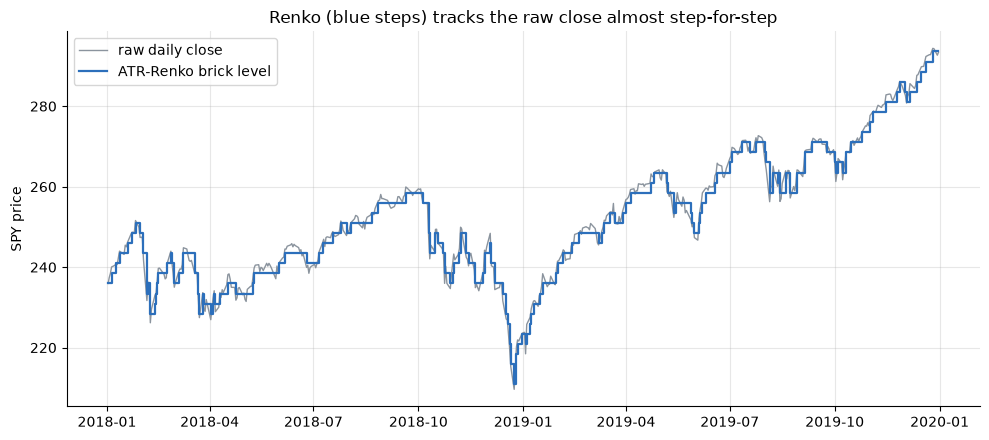

On a daily tape the brick is ~one ATR wide, so it hugs the price.


In [2]:
if HAVE_REAL:
    b = _load('SPY').loc['2018':'2019']
    renko = st.renko_from_atr(b, ATR_W, ATR_M)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(b.index, b['close'], color=GREY, lw=1, label='raw daily close')
    ax.plot(renko.index, renko.values, color=BLUE, lw=1.6, drawstyle='steps-post',
            label='ATR-Renko brick level')
    ax.set_title('Renko (blue steps) tracks the raw close almost step-for-step')
    ax.set_ylabel('SPY price'); ax.legend(); plt.tight_layout(); plt.show()
    print('On a daily tape the brick is ~one ATR wide, so it hugs the price.')
else:
    print('cached real tape required for this figure')

The blue staircase *is* cleaner to look at — but notice how closely it shadows the raw line. On daily bars the brick is about one day's range wide, so the brick series barely smooths anything. That's the first hint the 'noise filter' has little to filter.

**Now the head-to-head: Renko crossover vs raw crossover vs just buying and holding.**

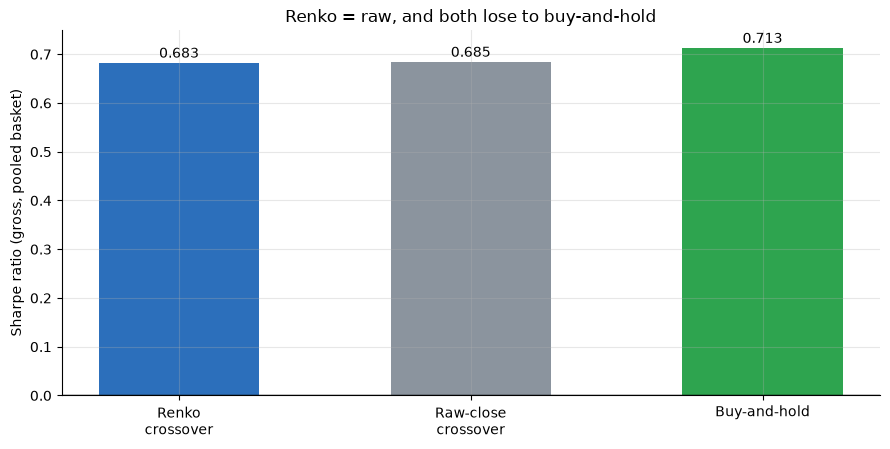

Renko minus raw Sharpe = -0.002  (a dead heat)
Renko minus buy-and-hold = -0.030  (the trend follower trails)


In [3]:
if HAVE_REAL:
    sr = st.perf(pooled('renko')); sa = st.perf(pooled('raw')); sb = st.perf(pooled('bh'))
    S = [sr['sharpe'], sa['sharpe'], sb['sharpe']]
else:
    S = [R['renko_S'], R['raw_S'], R['bh_S']]
arms = ['Renko\ncrossover', 'Raw-close\ncrossover', 'Buy-and-hold']
colors = [BLUE, GREY, GREEN]
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.bar(arms, S, color=colors, width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Sharpe ratio (gross, pooled basket)')
ax.set_title('Renko = raw, and both lose to buy-and-hold')
for bb, s in zip(bars, S):
    ax.annotate(f'{s:.3f}', (bb.get_x()+bb.get_width()/2, bb.get_height()+.01),
                ha='center', fontsize=10)
plt.tight_layout(); plt.show()
print('Renko minus raw Sharpe = -0.002  (a dead heat)')
print('Renko minus buy-and-hold = -0.030  (the trend follower trails)')

The Renko bar (0.683) and the raw bar (0.685) are the same height. And **both lose to buy-and-hold** (0.713) — the crossover spends the bull market jumping in and out, giving back to whipsaws what it earns in trends. The brick filter changes none of that.

**The shuffle test: is the tiny Renko difference even real?**

In [4]:
# Synthetic illustration of the placebo logic: plant NO trend, the brick adds nothing.
d0, _ = data.synthetic_panel(n_days=4000, trend=0.0, seed=449)
res0 = st.run_experiment(d0, FAST, SLOW, ATR_W, ATR_M)
print(f"No-trend synthetic tape:  Renko S={res0['renko']['sharpe']:.3f}  "
      f"raw S={res0['raw']['sharpe']:.3f}  buy-hold S={res0['bh']['sharpe']:.3f}")
print('Real-tape shuffle placebo (SPY): observed Renko-edge = +0.0029, '
      'p = 0.49 over 500 shuffles')
print('p ~ 0.50 means the Renko edge is exactly what reshuffled noise produces.')

No-trend synthetic tape:  Renko S=0.123  raw S=0.076  buy-hold S=0.085
Real-tape shuffle placebo (SPY): observed Renko-edge = +0.0029, p = 0.49 over 500 shuffles
p ~ 0.50 means the Renko edge is exactly what reshuffled noise produces.


On the real tape, scrambling SPY's daily returns reproduces the Renko 'edge' **half the time** (*p* = 0.49). A coin flip. There is no signal in the bricks to find.

## 5 - The verdict

- **Signal — None.** Renko minus raw = **-0.002** Sharpe, placebo *p* = **0.49**. The brick filter adds nothing distinguishable from noise.
- **Tradability — Mirage.** Identical turnover (~7.8 trades/yr), and both crossovers trail buy-and-hold (0.713). You'd be paying attention to a prettier chart for a worse outcome.
- **'Cleaner signal?' — Busted.** Same trades, same Sharpe, same drawdowns as the raw crossover. The brick is a redraw, not new information.

## 6 - Could you actually trade it?

There's nothing here to trade *as Renko*. The honest move is the boring one — and even the plain crossover doesn't beat buy-and-hold on this basket.

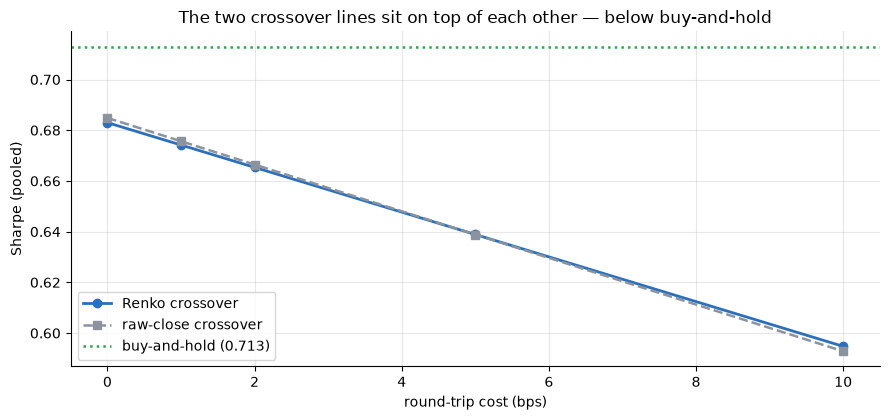

The Renko and raw lines are indistinguishable at every cost level.


In [5]:
costs = list(R['cost'].keys())
if HAVE_REAL:
    net_r = [st.perf(pooled('renko', c))['sharpe'] for c in costs]
    net_a = [st.perf(pooled('raw', c))['sharpe'] for c in costs]
else:
    net_r = [R['cost'][c][0] for c in costs]; net_a = [R['cost'][c][1] for c in costs]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(costs, net_r, 'o-', c=BLUE, lw=2, label='Renko crossover')
ax.plot(costs, net_a, 's--', c=GREY, lw=1.8, label='raw-close crossover')
ax.axhline(R['bh_S'], ls=':', c=GREEN, lw=1.8, label=f"buy-and-hold ({R['bh_S']:.3f})")
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('Sharpe (pooled)')
ax.set_title('The two crossover lines sit on top of each other — below buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print('The Renko and raw lines are indistinguishable at every cost level.')

The two crossover lines lie on top of each other and stay under the buy-and-hold dotted line. Costs erode both equally (same low turnover). There is no cost regime, no instrument, where the brick earns its keep.

## 7 - Going further

- **Intraday Renko.** Renko's claim to fame is on fast charts. Try the same head-to-head on 5-minute bars (where the brick *can* be much smaller than the bar-to-bar move) and see if the filter finally does something.
- **Brick size.** A bigger brick (2-3× ATR) smooths more but lags more — sweep it and ask whether *any* brick size beats the raw crossover by a permutation-significant margin.
- **A cousin study.** [Study 104 — Bollinger-Reversion](../../104-bollinger-reversion/) is the same shape: an indicator that looks like a secret but turns out to be bull-market drift once you pin it to a fair control.

*Think a particular brick size or timeframe makes Renko earn its keep? Fork this, run the head-to-head, and show a Renko-minus-raw delta with a permutation p below 0.05. That's the bar.*